---
title: "区分的定数分布による近似とサンプリング方法"
description: "区分的定数分布を用いて確率分布を近似し，効率的にサンプリングする方法を整理する"
date: 2025-10-05T09:00:00+09:00
date-modified: 2025-10-07T09:00:00+09:00
categories:
  - computerscience
draft: false
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hasenpfote/hasenpfote.github.io/blob/main/posts/sampling-with-piecewise-constant-distributions.ipynb)[]()

区分的定数分布とは，定義域を複数の区分（区間，セル，ビンなど）に分割し，それぞれの区分内で確率密度関数が一定値を取るように定義された確率分布である．  
このような分布は，解析的に扱いにくい密度関数を近似したり，モンテカルロ法・重要度サンプリングで効率的にサンプリングしたりするために広く利用される．

In [ ]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy.typing as npt
from typing import TypeAlias, overload

# from typing import overload

rng = np.random.default_rng(12345)

# print(plt.style.available)
plt.style.use("seaborn-v0_8")

## １次元の区分的定数分布

区間 $[0,1]$ を $\Delta=\frac{1}{N}$ で分割し，端点 $x_{i}=i\Delta\quad(i=0,\dots,N)$ とする．

$$
f(x)=
\begin{cases}
v_{0} \quad x_{0}\le x\lt x_{1}\\
v_{1} \quad x_{1}\le x\lt x_{2}\\
\vdots\\
v_{N-1} \quad x_{N-1}\le x\lt x_{N}\\
\end{cases}
$$

積分は，

$$
c
=\int_{0}^{1} f(x)\,dx
=\sum_{i=0}^{N-1} \int_{x_{i}}^{x_{i+1}} f(x)\,dx
=\sum_{i=0}^{N-1}v_{i}\Delta
=\sum_{i=0}^{N-1}\frac{v_{i}}{N}
$$

確率密度関数は，

$$
p(x)=\frac{f(x)}{c}
$$

累積分布関数は区分的に線形な関数となり，その値は各点 $x_{i}$ において次のように定義される．

$$
\begin{align*}
P(x_{0})&=0\\
P(x_{i})
&=\int_{x_{0}}^{x_{i}} p(x)\,dx
=\int_{x_{0}}^{x_{i-1}} p(x)\,dx+\int_{x_{i-1}}^{x_{i}} p(x)\,dx\\
&=P(x_{i-1})+\frac{v_{i-1}}{cN}
,\quad(i=1,\dots,N)
\end{align*}
$$

$[x_{i},x_{i+1})$ では，累積分布関数は傾き $v_{i}/c$ で線形に増加する．累積分布関数は単調増加なので，任意の $\zeta$ に対し $x$ の値は必ず $[x_{i},x_{i+1})$ に存在し，

$$
P(x_{i})\le\zeta\lt P(x_{i+1})
$$

が成り立つ．累積分布関数の値の配列が与えられていれば，このような $P(x_{i})$ の組は二分探索によって効率的に求めることができる．よって逆関数法によるサンプリングでは，対応する区間が決まれば $x$ の値は次のように与えられる．

$$
x=\left(i+\frac{\zeta-P(x_{i})}{P(x_{i+1})-P(x_{i})}\right)\Delta
$$

In [ ]:
class Distribution1D:
    def __init__(self, f: npt.NDArray[np.floating], *, dtype: npt.DTypeLike = np.float32) -> None:
        self.dtype = np.dtype(dtype)
        self.func = np.asarray(f, dtype=self.dtype)
        n = len(self.func)

        # Compute integral of step function at x_i
        self.cdf = np.zeros(n + 1, dtype=self.dtype)
        self.cdf[1:] = np.cumsum(self.func / n, axis=0)

        # Transform step function integral into CDF
        self.func_int = self.cdf[n]
        if self.func_int == self.dtype.type(0):
            self.cdf = np.linspace(0, 1, n + 1, dtype=self.dtype)
        else:
            self.cdf /= self.func_int

    def count(self) -> int:
        return len(self.func)

    @overload
    def sample_continuous(self, u: float | np.floating) -> tuple[np.floating, np.floating, np.int32]: ...

    @overload
    def sample_continuous(self, u: npt.NDArray[np.floating]) -> tuple[npt.NDArray[np.floating], npt.NDArray[np.floating], npt.NDArray[np.int32]]: ...

    def sample_continuous(self, u):
        u = np.asarray(u, dtype=self.dtype)

        # Find surrounding CDF segments and offset
        offset = np.searchsorted(self.cdf, u, side="right") - 1
        offset = np.clip(offset, 0, len(self.cdf) - 2).astype(np.int32)

        # Compute offset along CDF segment
        du = u - self.cdf[offset]
        seg = self.cdf[offset + 1] - self.cdf[offset]
        du = np.where(seg > self.dtype.type(0), du / seg, du)

        # Compute PDF for sampled offset
        x = (offset.astype(self.dtype) + du) / self.count()
        pdf = self.func[offset] / self.func_int

        # Return x in [0,1) corresponding to sample
        if np.ndim(u) == 0:
            return x[()], pdf[()], offset[()]

        return x, pdf, offset

    @overload
    def sample_discrete(self, u: float | np.floating) -> tuple[np.int32, np.floating, np.floating]: ...

    @overload
    def sample_discrete(self, u: npt.NDArray[np.floating]) -> tuple[npt.NDArray[np.int32], npt.NDArray[np.floating], npt.NDArray[np.floating]]: ...

    def sample_discrete(self, u):
        u = np.asarray(u, dtype=self.dtype)

        # Find surrounding CDF segments and offset
        offset = np.searchsorted(self.cdf, u, side="right") - 1
        offset = np.clip(offset, 0, len(self.cdf) - 2).astype(np.int32)

        pdf = self.func[offset] / (self.func_int * self.count())
        u_remapped = (u - self.cdf[offset]) / (self.cdf[offset + 1] - self.cdf[offset])

        if np.ndim(u) == 0:
            return offset[()], pdf[()], u_remapped[()]

        return offset, pdf, u_remapped

    @overload
    def discrete_pdf(self, index: int | np.integer) -> np.floating: ...

    @overload
    def discrete_pdf(self, index: npt.NDArray[np.integer]) -> npt.NDArray[np.floating]: ...

    def discrete_pdf(self, index):
        return self.func[index] / (self.func_int * self.count())

In [ ]:
def histogram_1d(sampler, sample_size, batch_size, rng, bins, range=None):
    dtype = sampler(1, rng).dtype
    if isinstance(bins, int):
        edges = np.linspace(*range, bins + 1, dtype=dtype)
    else:
        edges = np.asarray(bins, dtype=dtype)

    H_total = np.zeros(len(edges) - 1, dtype=np.int64)
    remaining = sample_size

    while remaining > 0:
        current_batch = min(batch_size, remaining)
        samples = sampler(current_batch, rng)
        H_batch, _ = np.histogram(samples, bins=edges, range=range, density=False)
        H_total += H_batch
        remaining -= current_batch

        del samples, H_batch
        gc.collect()

    H_density = H_total / (sample_size * np.diff(edges))

    return H_density, edges


def plot_distribution_1d(distr: Distribution1D, sample_size: int, rng: np.random.Generator) -> None:
    n = distr.count()
    x = np.linspace(0, 1, n + 1, dtype=distr.dtype)
    indices = np.arange(distr.count())

    def continuous_sampler(sample_size: int, rng: np.random.Generator):
        return distr.sample_continuous(rng.random(sample_size, dtype=distr.dtype))[0]

    def discrete_sampler(sample_size: int, rng: np.random.Generator):
        return distr.sample_discrete(rng.random(sample_size, dtype=distr.dtype))[0]

    data = [
        {"title": "Input function f", "ylabel": "f(x)", "plot_fn": lambda ax: ax.step(x[:-1], distr.func, where="post", linewidth=1)},
        {"title": "CDF", "ylabel": "CDF(x)", "plot_fn": lambda ax: ax.step(x, distr.cdf, where="post", linewidth=1)},
        {
            "title": f"Cont. PDF (N={sample_size})",
            "ylabel": "Density",
            "legend": True,
            "data_fn": lambda: (
                histogram_1d(continuous_sampler, sample_size, 100000, rng, bins=x),
                distr.func[indices] / distr.func_int,
            ),
            "plot_fn": lambda ax, hist_data, pdf: (
                ax.bar(hist_data[1][:-1], hist_data[0], width=np.diff(hist_data[1]), align="edge", alpha=0.6, label="sample histogram"),
                ax.step(hist_data[1][:-1], pdf, where="post", color="red", linestyle="--", linewidth=1, alpha=0.6, label="Theoretical PDF"),
            ),
        },
        {
            "title": f"Disc. PMF (N={sample_size})",
            "ylabel": "Probability",
            "legend": True,
            "data_fn": lambda: (
                histogram_1d(discrete_sampler, sample_size, 100000, rng, bins=np.arange(distr.count() + 1)),
                distr.discrete_pdf(indices),
            ),
            "plot_fn": lambda ax, hist_data, pdf: (
                ax.bar(hist_data[1][:-1], hist_data[0], width=np.diff(hist_data[1]), align="edge", alpha=0.6, label="sample histogram"),
                ax.step(hist_data[1][:-1], pdf, where="post", color="red", linestyle="--", linewidth=1, alpha=0.6, label="Theoretical PMF"),
            ),
        },
    ]

    nrows_ncols = (1, len(data))
    base_w, base_h = plt.rcParams.get("figure.figsize")
    figsize = (base_w * nrows_ncols[1], base_h * nrows_ncols[0])

    subplot_kw = {"xlabel": "x"}
    fig, axs = plt.subplots(nrows=nrows_ncols[0], ncols=nrows_ncols[1], subplot_kw=subplot_kw, figsize=figsize)
    axs = np.atleast_1d(axs).flatten()

    for ax, datum in zip(axs, data):
        res = ()
        if "data_fn" in datum:
            res = datum["data_fn"]()  # type: ignore

        datum["plot_fn"](ax, *res)  # type: ignore

        ax.set_title(datum["title"])
        ax.set_ylabel(datum["ylabel"])
        ax.grid(True)

        if datum.get("legend"):
            ax.legend()

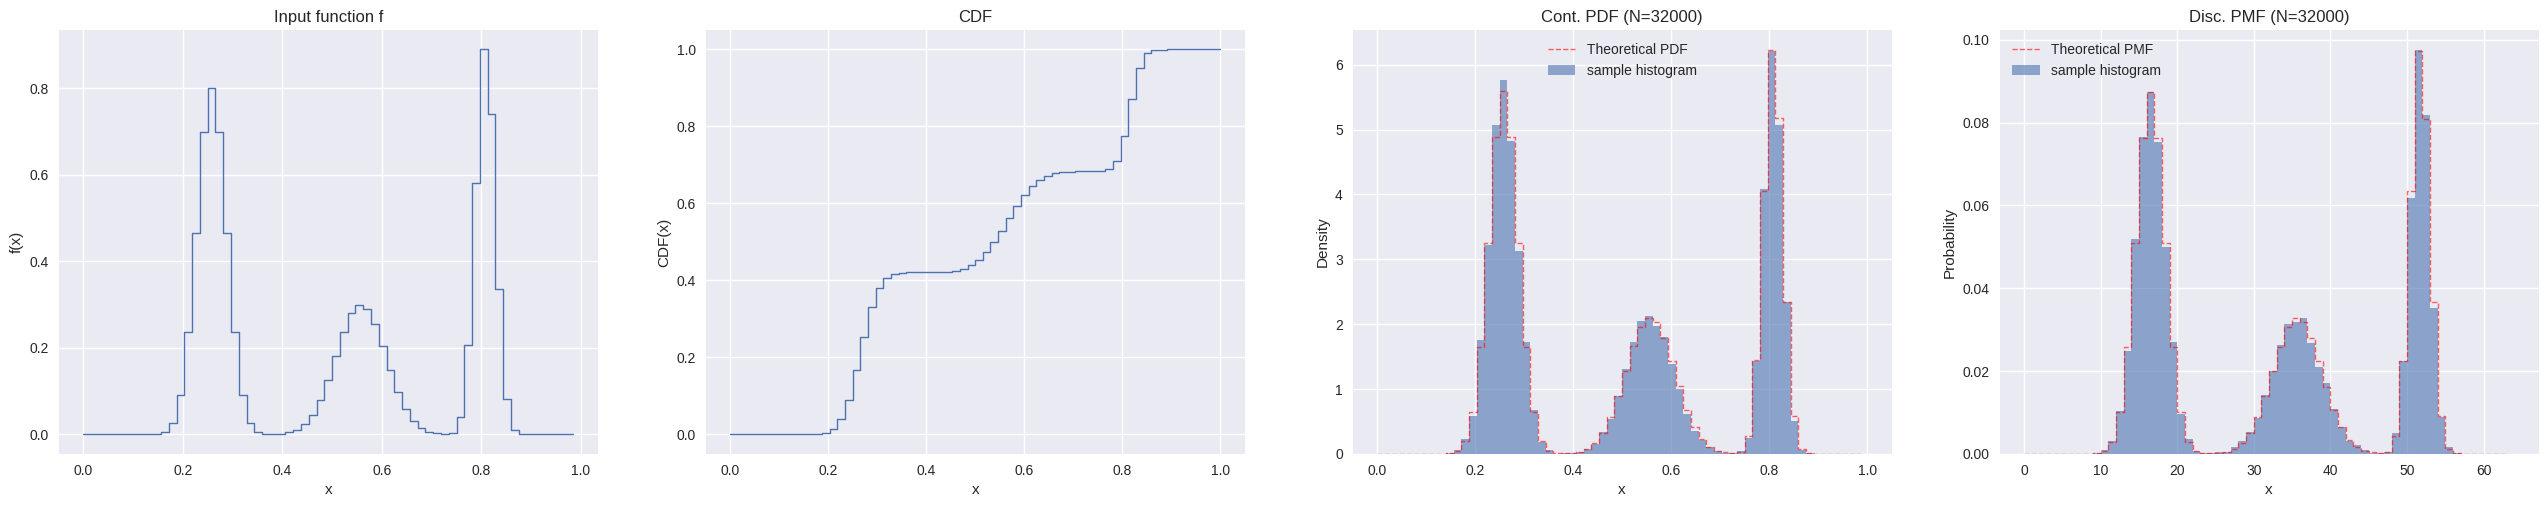

In [ ]:
def gaussian1d(x, x0, sigma):
    return np.exp(-((x - x0) ** 2) / (2 * sigma**2))


x = np.linspace(0, 1, 64 + 1)

peaks_1d = [(0.25, 0.03, 0.8), (0.55, 0.05, 0.3), (0.8, 0.02, 0.9)]

f = sum(a * gaussian1d(x, x0, s) for x0, s, a in peaks_1d)
f = f[:-1].astype(np.float32)

plot_distribution_1d(Distribution1D(f), 500 * f.size, rng)

## ２次元の区分的定数分布


２次元関数 $f(u,v)$ が，$u_{i}\in[0,1,\dots,n_{u}-1],\,v_{j}\in[0,1,\dots,n_{v}-1]$ に対して $f[u_{i},v_{j}]$ の値によって定義され，$f[u_{i},v_{j}]$ は範囲 $[\frac{i}{n_{u}},\frac{i+1}{n_{u}})\times[\frac{j}{n_{v}},\frac{j+1}{n_{v}})$ で一定の値を取るとする．連続値 $(u,v)$ が与えられたとき，対応する離散インデクス $(\tilde{u},\tilde{v})$ を $\tilde{u}=\lfloor n_{u}u\rfloor,\,\tilde{v}=\lfloor n_{v}v\rfloor$ と定義し，$f(u,v)=f[\tilde{u},\tilde{v}]$ とする．  


$f$ の積分は $f[u_{i},v_{j}]$ の値の単純な和になる．

$$
I_{f}
=\iint_{[0,1]^{2}} f(u,v)\,dudv
=\sum_{i=0}^{n_{u}-1}\sum_{j=0}^{n_{v}-1}\int_{\frac{i}{n_{u}}}^{\frac{i+1}{n_{u}}}\int_{\frac{j}{n_{v}}}^{\frac{j+1}{n_{v}}} f[u_{i},v_{j}]\,dvdu\\
=\frac{1}{n_{u}n_{v}}\sum_{i=0}^{n_{u}-1}\sum_{j=0}^{n_{v}-1} f[u_{i},v_{j}]
$$

$f$ の同時確率密度関数は，

$$
p(u,v)
=\frac{f(u,v)}{I_{f}}
=\frac{f[\tilde{u},\tilde{v}]}{\frac{1}{n_{u}n_{v}}\sum_{i=0}^{n_{u}-1}\sum_{j=0}^{n_{v}-1} f[u_{i},v_{j}]}
$$

周辺確率密度関数は，$f[u_{i},v_{j}]$ の値の和として計算できる．

$$
p(v)
=\int_{0}^{1} p(u,v)\,du
=\frac{1}{I_{f}}\int_{0}^{1} f(u,v)\,du
=\frac{\frac{1}{n_{u}}\sum_{i=0}^{n_{u}-1} f[u_{i},\tilde{v}]}{I_{f}}
$$

この関数は，$\tilde{v}$ にのみ依存するため，$n_{v}$ 個の値で定義される区分的定数１次元関数 $p[\tilde{v}]$ となる．$v$ のサンプルが与えられたとき，条件付き確率密度関数は，

$$
p(u|v)
=\frac{p(u,v)}{p(v)}
=\frac{\frac{f[\tilde{u},\tilde{v}]}{I_{f}}}{p[\tilde{v}]}
=\frac{f[\tilde{u},\tilde{v}]}{\frac{1}{n_{u}}\sum_{i=0}^{n_{u}-1} f[u_{i},\tilde{v}]}
$$

特定の $\tilde{v}$ の値が与えられたとき，$p[\tilde{u}|\tilde{v}]$ は $\tilde{u}$ の区分的定数１次関数であり，通常の１次元手法でサンプリングが可能である．$\tilde{v}$ の各値に対して $n_{v}$ 個の異なる１次元条件付き密度が存在する．

In [ ]:
class Distribution1DBatch:
    def __init__(self, funcs: npt.NDArray[np.floating], *, dtype: npt.DTypeLike = np.float32):
        # funcs: shape (M, N)   (M distributions, each length N)
        self.dtype = np.dtype(dtype)
        self.func = np.asarray(funcs, dtype=self.dtype)
        M, N = self.func.shape

        # Compute integral of step function at x_i
        self.cdf = np.zeros((M, N + 1), dtype=self.dtype)
        self.cdf[:, 1:] = np.cumsum(self.func / N, axis=1)

        # Transform step function integral into CDF
        self.func_int = self.cdf[:, -1].copy()
        mask = self.func_int == self.dtype.type(0)
        self.cdf[mask] = np.linspace(0, 1, N + 1, dtype=self.dtype)
        mask = ~mask
        self.cdf[mask] /= self.func_int[mask, None]

    def sample_continuous(self, u: npt.NDArray[np.floating], batch_idx: npt.NDArray[np.integer]) -> tuple[npt.NDArray[np.floating], npt.NDArray[np.floating], npt.NDArray[np.int32]]:
        u = np.asarray(u, dtype=self.dtype)
        rows = batch_idx
        cdf_rows = self.cdf[rows]
        _, N = self.func.shape

        # Find surrounding CDF segments and offset
        cols = (cdf_rows[:, 1:] <= u[:, None]).sum(axis=1)  # vectorized searchsorted
        cols = np.clip(cols, 0, N - 1, dtype=np.int32)

        # Compute offset along CDF segment
        row_idx = np.arange(len(u))
        du = u - cdf_rows[row_idx, cols]
        seg = cdf_rows[row_idx, cols + 1] - cdf_rows[row_idx, cols]
        du = np.where(seg > self.dtype.type(0), du / seg, du)

        # Return x in [0,1) corresponding to sample
        x = (cols.astype(self.dtype) + du) / N
        pdf = self.func[rows, cols] / self.func_int[rows]

        return x, pdf, cols


class Distribution2D:
    def __init__(self, func: npt.NDArray[np.floating], *, dtype: npt.DTypeLike = np.float32) -> None:
        self.dtype = np.dtype(dtype)
        nv, nu = func.shape

        # Compute conditional sampling distribution for v_tilde
        self.conditional_v = Distribution1DBatch(func, dtype=self.dtype)

        # Compute marginal sampling distribution p[v_tilde]
        marginal_func = self.conditional_v.func_int
        self.marginal = Distribution1D(marginal_func, dtype=self.dtype)

    def sample_continuous(self, u):
        u = np.asarray(u, dtype=self.dtype)
        is_single = u.ndim == 1
        u = np.atleast_2d(u)

        d1, pdf1, v = self.marginal.sample_continuous(u[:, 1])
        d0, pdf0, _ = self.conditional_v.sample_continuous(u[:, 0], v)

        x = np.stack([d0, d1], axis=-1)
        pdf = pdf0 * pdf1

        if is_single:
            return np.squeeze(x, axis=0), np.squeeze(pdf, axis=0)[()]

        return x, pdf

    def pdf(self, p):
        p = np.asarray(p, dtype=self.dtype)
        is_single = p.ndim == 1
        p = np.atleast_2d(p)

        nv, nu = self.conditional_v.func.shape

        iu = np.clip((p[:, 0] * nu).astype(np.int32), 0, nu - 1)
        iv = np.clip((p[:, 1] * nv).astype(np.int32), 0, nv - 1)

        pdf = self.conditional_v.func[iv, iu] / self.marginal.func_int

        if is_single:
            return np.squeeze(pdf, axis=0)[()]

        return pdf

In [ ]:
def histogram_2d(sampler, sample_size, batch_size, rng, bins, range=None):
    dtype = sampler(1, rng).dtype
    if isinstance(bins, int):
        xedges = np.linspace(*range, bins + 1, dtype=dtype)
        yedges = np.linspace(*range, bins + 1, dtype=dtype)
    elif isinstance(bins[0], int) and isinstance(bins[1], int):
        xedges = np.linspace(*range[0], bins[0] + 1, dtype=dtype)
        yedges = np.linspace(*range[1], bins[1] + 1, dtype=dtype)
    else:
        xedges = np.asarray(bins[0])
        yedges = np.asarray(bins[1])

    H_total = np.zeros((len(xedges) - 1, len(yedges) - 1))
    remaining = sample_size

    while remaining > 0:
        current_batch = min(batch_size, remaining)
        samples = sampler(current_batch, rng)
        H_batch, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], bins=(xedges, yedges), range=range, density=False)
        H_total += H_batch
        remaining -= current_batch

        del samples, H_batch
        gc.collect()

    area = np.diff(xedges)[:, None] * np.diff(yedges)[None, :]
    H_density = H_total / (sample_size * area)

    return H_density, xedges, yedges


def plot_distribution_2d(distr: Distribution2D, sample_size: int, rng: np.random.Generator) -> None:
    def gen_marginal_pdf():
        indices = np.arange(distr.marginal.count())
        pdf = distr.marginal.func[indices] / distr.marginal.func_int
        return pdf[:, None]

    def gen_pdf():
        nv, nu = distr.conditional_v.func.shape
        u = np.linspace(0, 1, nu + 1, dtype=distr.dtype)[:-1]
        v = np.linspace(0, 1, nv + 1, dtype=distr.dtype)[:-1]
        U, V = np.meshgrid(u, v)
        points = np.stack([U.ravel(), V.ravel()], axis=-1)
        return distr.pdf(points).reshape(nv, nu)

    def gen_histogram():
        sampler = lambda sample_size, rng: distr.sample_continuous(rng.random((sample_size, 2), dtype=distr.dtype))[0]
        H, _, _ = histogram_2d(sampler, sample_size, 100000, rng, bins=(nu, nv), range=((0, 1), (0, 1)))
        return H.T

    nv, nu = distr.conditional_v.func.shape

    data = [
        {"title": "Input function f", "data_fn": lambda: distr.conditional_v.func, "width": nu},
        {"title": "", "hide_cbar": True, "hide_xticks": True, "data_fn": gen_marginal_pdf, "width": 1},
        {"title": "Theoretical PDF", "hide_yticks": True, "sharey_with": 1, "data_fn": gen_pdf, "width": nu},
        {"title": f"Sampled PDF (N={sample_size})", "data_fn": gen_histogram, "width": nu},
    ]

    aspect_ratio = nv / nu
    subplot_width = 5
    subplot_height = subplot_width * aspect_ratio
    figsize = (subplot_width * (len(data) - 1), subplot_height)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.1)
    gs = gridspec.GridSpec(1, len(data), figure=fig, width_ratios=[datum["width"] for datum in data])
    axs = [fig.add_subplot(gs[i]) for i in range(len(data))]

    xticks = np.linspace(0, nu - 1, 6)
    xticklabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
    yticks = np.linspace(0, nv - 1, 6)
    yticklabels = [f"{y:.1f}" for y in np.linspace(0, 1, 6)]

    for ax, datum in zip(axs, data):
        X = datum["data_fn"]()  # type: ignore
        ny, nx = X.shape
        im = ax.imshow(X, cmap="gray", aspect="equal", interpolation="nearest", extent=[0, nx, 0, ny])
        ax.set_title(datum["title"])
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)
        ax.set_xlim(0, nx)
        ax.set_ylim(0, ny)
        ax.grid(False)

        if datum.get("hide_xticks"):
            ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        if datum.get("hide_yticks"):
            ax.tick_params(axis="y", which="both", left=False, labelleft=False)

        if "sharey_with" in datum:
            ax.sharey(axs[datum["sharey_with"]])

        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.set_visible(not datum.get("hide_cbar", False))

    plt.show()

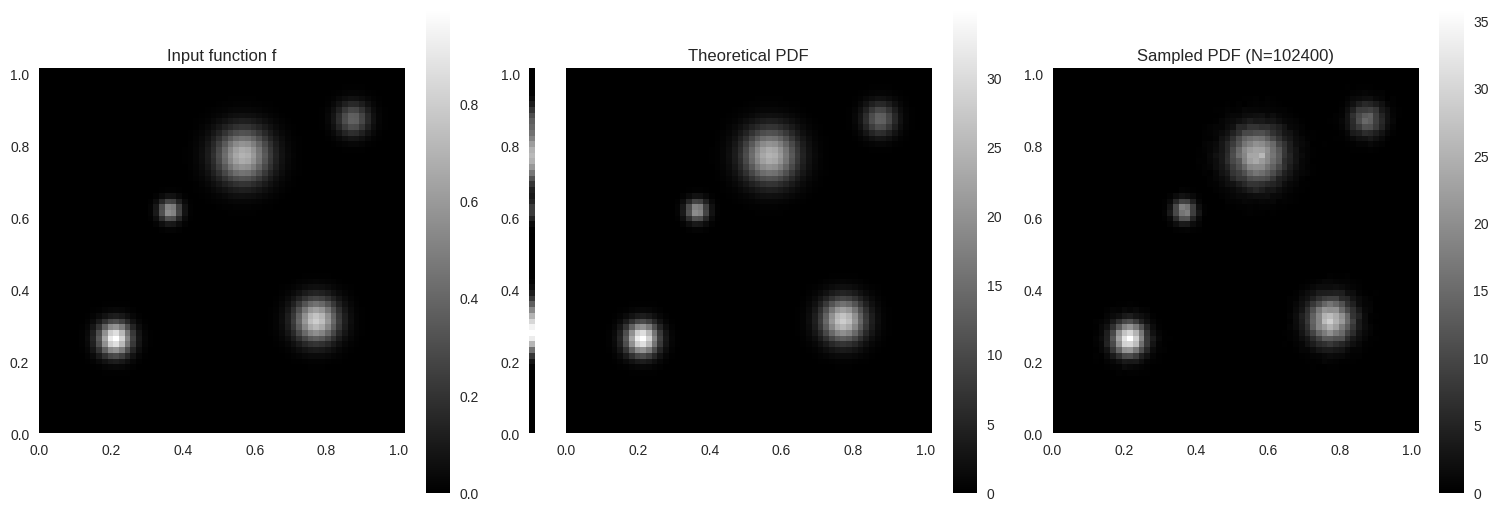

In [ ]:
def gaussian2d(x, y, x0, y0, sigma):
    return np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma**2))


nu, nv = 64, 64
u_edges = np.linspace(0, 1, nu + 1)[:-1]
v_edges = np.linspace(0, 1, nv + 1)[:-1]
U, V = np.meshgrid(u_edges, v_edges)

peaks_2d = [
    (0.20, 0.25, 0.03, 1.0),
    (0.75, 0.30, 0.04, 0.8),
    (0.55, 0.75, 0.05, 0.7),
    (0.35, 0.60, 0.02, 0.6),
    (0.85, 0.85, 0.03, 0.4),
]

f = sum(a * gaussian2d(U, V, u0, v0, s) for u0, v0, s, a in peaks_2d)
f = f[::-1]
f = f.astype(np.float32)

plot_distribution_2d(Distribution2D(f), 25 * f.size, rng)

## 使用例

球面上の方向 $\omega$ を選ぶ確率は，その方向の輝度 $L(\omega)$ に比例すると考えられる．微小な立体角要素 $d\omega$ を用いると，

$$
p_{\Omega}(\omega)\,d\omega
\propto L(\omega)\,d\omega
$$

と書ける．立体角要素は，

$$
d\omega
=\sin\theta\,d\theta d\phi
$$

であるため，球面座標では，

$$
p_{\Theta,\Phi}(\theta,\phi)\,d\theta d\phi
\propto L(\theta,\phi)\sin\theta\,d\theta d\phi
$$

となる．環境マップの画像座標 $(u,v)$ を，

$$
u=\frac{\phi}{2\pi}
\,\quad
v=\frac{\theta}{\pi}
$$

とすると，ヤコビアンより，

$$
d\theta d\phi
=\left|\frac{\partial(\theta,\phi)}{\partial(u,v)}\right|\,dudv
=2\pi^{2}\,dudv
$$

が得られる．これを代入すると，

$$
p_{\Theta,\Phi}(\theta,\phi)\,d\theta d\phi
\propto L(\theta,\phi)\sin\theta (2\pi^{2}\,dudv)
$$

すなわち，

$$
p_{U,V}(u,v)\,dudv
\propto L(u,v)\sin(\pi v) (2\pi^{2}\,dudv)
$$

となる．比例定数は正規化により相殺されるため，

$$
p_{U,V}(u,v)
\propto L(u,v)\sin(\pi v)
$$

を得る．

In [ ]:
from PIL import Image
import requests
from io import BytesIO


def load_image_from_url(url):
    response = requests.get(url)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    return img


img = load_image_from_url("https://www.pbr-book.org/3ed-2018/Monte_Carlo_Integration/hdr-env-orig.png")

In [ ]:
img_np = np.array(img.convert("RGB"), dtype=np.float32) / 255.0
height, width, _ = img_np.shape

coeff = np.array([0.2126, 0.7152, 0.0722], dtype=img_np.dtype)
luminance = np.dot(img_np, coeff)

v = np.arange(height)
sin_theta = np.sin(np.pi * (v + 0.5) / height)
luminance *= sin_theta[:, None]

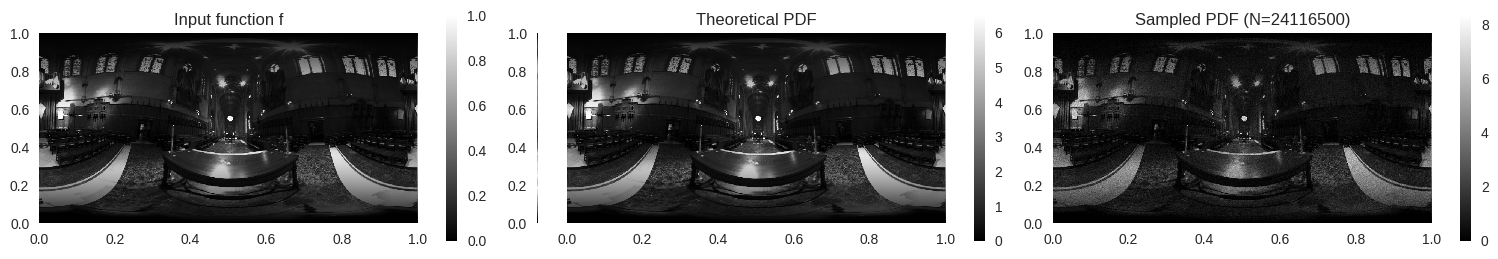

In [ ]:
plot_distribution_2d(Distribution2D(luminance), 25 * luminance.size, rng)

## References

- Pharr, M., Jakob, W., & Humphreys, G. (n.d.). Sampling Random Variables. Physically Based Rendering: From Theory To Implementation. <https://www.pbr-book.org/3ed-2018/Monte_Carlo_Integration/Sampling_Random_Variables>
- Pharr, M., Jakob, W., & Humphreys, G. (n.d.). 2D sampling with multidimensional transformations. Physically Based Rendering: From Theory To Implementation. <https://www.pbr-book.org/3ed-2018/Monte_Carlo_Integration/2D_Sampling_with_Multidimensional_Transformations>
- Pharr, M., Jakob, W., & Humphreys, G. (n.d.). Sampling Light Sources. Physically Based Rendering: From Theory To Implementation. <https://www.pbr-book.org/3ed-2018/Light_Transport_I_Surface_Reflection/Sampling_Light_Sources>